# Graph Mining Project — IEEE 118 Cascade Analysis

This notebook contains a clean end-to-end workflow for the IEEE 118-bus case.

It includes:
- network loading and baseline power flow
- graph construction
- graph metrics for nodes and edges
- edge-triggered cascade simulation
- node-triggered cascade simulation
- comparison of graph metrics against simulation criticality
- sensitivity analysis
- the added node metrics: closeness and eigenvector centrality

## 1. Imports and experiment settings

In [1]:
import copy
from itertools import product

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.networks as pn

from scipy.stats import pearsonr, spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

BASE_ALPHA = 0.20
BASE_MIN_LOADING = 0.10

## 2. Load the IEEE 118-bus system and solve the baseline operating point

In [2]:
net = pn.case118()
pp.runpp(net)

print("Buses:", len(net.bus))
print("Lines:", len(net.line))
print("Loads:", len(net.load))
print("Generators:", len(net.gen))
print("Baseline max line loading (%):", net.res_line.loading_percent.max())

Buses: 118
Lines: 173
Loads: 99
Generators: 53
Baseline max line loading (%): 4.4750873243376645


## 3. Build the bus graph

In [3]:
def build_graph_from_net(net_obj):
    G = nx.Graph()

    for bus_id in net_obj.bus.index:
        G.add_node(int(bus_id))

    active_lines = net_obj.line[net_obj.line["in_service"] == True]

    for line_id, row in active_lines.iterrows():
        G.add_edge(
            int(row["from_bus"]),
            int(row["to_bus"]),
            line_id=int(line_id)
        )

    return G


G = build_graph_from_net(net)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 118
Edges: 166


## 4. Compute graph metrics

In [4]:
degree_dict = dict(G.degree())
node_betweenness_dict = nx.betweenness_centrality(G, normalized=True)
closeness_dict = nx.closeness_centrality(G)

try:
    eigenvector_dict = nx.eigenvector_centrality(G, max_iter=5000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge.")
    eigenvector_dict = {node: np.nan for node in G.nodes()}

edge_betweenness_raw = nx.edge_betweenness_centrality(G, normalized=True)

node_cent_df = pd.DataFrame({
    "bus_id": list(G.nodes()),
    "degree": [degree_dict[n] for n in G.nodes()],
    "node_betweenness": [node_betweenness_dict[n] for n in G.nodes()],
    "closeness": [closeness_dict[n] for n in G.nodes()],
    "eigenvector": [eigenvector_dict[n] for n in G.nodes()]
}).sort_values("node_betweenness", ascending=False)

edge_cent_rows = []
for (u, v), eb in edge_betweenness_raw.items():
    edge_cent_rows.append({
        "line_id": int(G[u][v]["line_id"]),
        "from_bus": int(u),
        "to_bus": int(v),
        "edge_betweenness": eb
    })

edge_cent_df = pd.DataFrame(edge_cent_rows).sort_values("edge_betweenness", ascending=False)

print("Top 10 nodes by node betweenness")
print(node_cent_df[["bus_id", "degree", "node_betweenness", "closeness", "eigenvector"]].head(10))

print("\nTop 10 edges by edge betweenness")
print(edge_cent_df.head(10))

Top 10 nodes by node betweenness
    bus_id  degree  node_betweenness  closeness  eigenvector
76      76       6          0.358312   0.185259     0.235613
48      48       9          0.348221   0.192995     0.295946
68      68       5          0.346251   0.197954     0.263811
79      79       6          0.220349   0.166867     0.210801
69      69       5          0.209553   0.183058     0.164423
23      23       3          0.185385   0.170248     0.051269
22      22       4          0.181974   0.159662     0.016799
99      99       8          0.174114   0.138183     0.301774
41      41       3          0.154862   0.175750     0.091045
39      39       4          0.143979   0.164200     0.038459

Top 10 edges by edge betweenness
     line_id  from_bus  to_bus  edge_betweenness
103      109        68      76          0.272776
77        97        48      68          0.264295
115      114        76      79          0.219882
37        99        23      69          0.183112
34        28     

## 5. Cascade simulation helpers

In [5]:
def build_active_graph(net_obj):
    G_active = nx.Graph()

    for bus_id in net_obj.bus.index:
        G_active.add_node(int(bus_id))

    active_lines = net_obj.line[net_obj.line["in_service"] == True]

    for line_id, row in active_lines.iterrows():
        G_active.add_edge(
            int(row["from_bus"]),
            int(row["to_bus"]),
            line_id=int(line_id)
        )

    return G_active


def compute_load_shed(net_obj):
    total_load = net_obj.load["p_mw"].sum()

    active_buses = set()
    active_lines = net_obj.line[net_obj.line["in_service"] == True]

    for _, row in active_lines.iterrows():
        active_buses.add(int(row["from_bus"]))
        active_buses.add(int(row["to_bus"]))

    served_load = net_obj.load[net_obj.load["bus"].isin(active_buses)]["p_mw"].sum()
    shed_load = total_load - served_load
    shed_percent = 100.0 * shed_load / total_load if total_load > 0 else 0.0

    return served_load, shed_load, shed_percent


def run_cascade(net_obj, initial_line=None, initial_lines=None, alpha=0.20, min_base_loading=0.10):
    netc = copy.deepcopy(net_obj)

    baseline_loading = net_obj.res_line.loading_percent.copy()
    threshold = baseline_loading.clip(lower=min_base_loading) * (1.0 + alpha)

    if initial_lines is None:
        if initial_line is None:
            raise ValueError("Provide either initial_line or initial_lines")
        initial_lines = [int(initial_line)]
    else:
        initial_lines = [int(x) for x in initial_lines]

    tripped_lines = []

    for line_id in initial_lines:
        netc.line.at[line_id, "in_service"] = False
        tripped_lines.append(int(line_id))

    iterations = 0

    while True:
        iterations += 1

        try:
            pp.runpp(netc)
        except Exception:
            G_active = build_active_graph(netc)
            lcc_size = len(max(nx.connected_components(G_active), key=len)) if G_active.number_of_edges() > 0 else 1
            served_load, shed_load, shed_percent = compute_load_shed(netc)

            return {
                "initial_line": int(initial_lines[0]) if len(initial_lines) == 1 else None,
                "initial_lines": initial_lines,
                "cascade_size": len(tripped_lines),
                "tripped_lines": tripped_lines,
                "iterations": iterations,
                "solver_failed": True,
                "lcc_size": lcc_size,
                "served_load_mw": served_load,
                "shed_load_mw": shed_load,
                "shed_percent": shed_percent
            }

        current_loading = netc.res_line.loading_percent.copy()
        active_mask = netc.line["in_service"] == True
        overload_mask = active_mask & (current_loading > threshold)

        newly_overloaded = [
            int(line_id)
            for line_id in netc.line.index[overload_mask].tolist()
            if int(line_id) not in tripped_lines
        ]

        if len(newly_overloaded) == 0:
            break

        for line_id in newly_overloaded:
            netc.line.at[line_id, "in_service"] = False
            tripped_lines.append(int(line_id))

    G_active = build_active_graph(netc)
    lcc_size = len(max(nx.connected_components(G_active), key=len)) if G_active.number_of_edges() > 0 else 1
    served_load, shed_load, shed_percent = compute_load_shed(netc)

    return {
        "initial_line": int(initial_lines[0]) if len(initial_lines) == 1 else None,
        "initial_lines": initial_lines,
        "cascade_size": len(tripped_lines),
        "tripped_lines": tripped_lines,
        "iterations": iterations,
        "solver_failed": False,
        "lcc_size": lcc_size,
        "served_load_mw": served_load,
        "shed_load_mw": shed_load,
        "shed_percent": shed_percent
    }


def run_node_cascade(net_obj, bus_id, alpha=0.20, min_base_loading=0.10):
    incident_lines = net_obj.line.index[
        (net_obj.line["from_bus"] == bus_id) | (net_obj.line["to_bus"] == bus_id)
    ].tolist()

    result = run_cascade(
        net_obj,
        initial_lines=incident_lines,
        alpha=alpha,
        min_base_loading=min_base_loading
    )

    result["initial_bus"] = int(bus_id)
    result["incident_line_count"] = len(incident_lines)
    return result

In [6]:
sanity_result = run_cascade(net, initial_line=0, alpha=BASE_ALPHA, min_base_loading=BASE_MIN_LOADING)
print(sanity_result)

{'initial_line': 0, 'initial_lines': [0], 'cascade_size': 99, 'tripped_lines': [0, 1, 15, 17, 18, 28, 40, 49, 51, 14, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 33, 41, 44, 45, 52, 53, 55, 99, 102, 42, 43, 89, 60, 59, 64, 63, 136, 54, 57, 58, 73, 96, 112, 113, 114, 72, 77, 78, 104, 105, 109, 111, 116, 117, 118, 119, 120, 122, 123, 124, 130, 139, 140, 171, 172, 65, 68, 75, 76, 106, 107, 110, 128, 129, 131, 132, 133, 134, 135, 137, 138, 141, 142, 143, 144, 145, 146, 147, 148, 149, 69, 80, 81, 82, 86, 93, 94, 87, 97], 'iterations': 13, 'solver_failed': False, 'lcc_size': 11, 'served_load_mw': np.float64(2675.0), 'shed_load_mw': np.float64(1567.0), 'shed_percent': np.float64(36.94012258368694)}


## 6. Full edge-triggered cascade scan

In [7]:
edge_results = []

for line_id in net.line.index:
    edge_results.append(
        run_cascade(
            net,
            initial_line=int(line_id),
            alpha=BASE_ALPHA,
            min_base_loading=BASE_MIN_LOADING
        )
    )

cascade_df = pd.DataFrame(edge_results)
print(cascade_df.sort_values(["shed_percent", "cascade_size"], ascending=False).head(10))

     initial_line initial_lines  cascade_size                                      tripped_lines  iterations  solver_failed  lcc_size  served_load_mw  \
19             19          [19]            99  [19, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 2...           8          False        23          2323.0   
25             25          [25]            87  [25, 22, 23, 24, 28, 40, 41, 46, 49, 99, 102, ...           8          False        28          2518.0   
26             26          [26]            90  [26, 22, 23, 24, 28, 166, 32, 38, 40, 41, 46, ...           8          False        21          2536.0   
27             27          [27]            80  [27, 21, 22, 23, 24, 28, 32, 37, 38, 41, 165, ...           9          False        32          2536.0   
125           125         [125]            98  [125, 126, 127, 130, 110, 116, 117, 118, 119, ...          15          False        15          2561.0   
126           126         [126]            98  [126, 125, 127, 130, 110, 116, 117,

## 7. Compare edge betweenness against simulated edge criticality

In [8]:
edge_compare_df = edge_cent_df.merge(
    cascade_df[["initial_line", "cascade_size", "shed_percent", "lcc_size", "solver_failed"]],
    left_on="line_id",
    right_on="initial_line",
    how="left"
)

valid_edge_compare = edge_compare_df[edge_compare_df["solver_failed"] == False].copy()

edge_summary = pd.DataFrame([{
    "pearson_betweenness_vs_shed": pearsonr(valid_edge_compare["edge_betweenness"], valid_edge_compare["shed_percent"])[0],
    "spearman_betweenness_vs_shed": spearmanr(valid_edge_compare["edge_betweenness"], valid_edge_compare["shed_percent"])[0],
    "pearson_betweenness_vs_cascade": pearsonr(valid_edge_compare["edge_betweenness"], valid_edge_compare["cascade_size"])[0],
    "spearman_betweenness_vs_cascade": spearmanr(valid_edge_compare["edge_betweenness"], valid_edge_compare["cascade_size"])[0]
}])

print(edge_summary)
print("\nTop 15 edge comparison rows")
print(edge_compare_df.sort_values(["shed_percent", "cascade_size", "edge_betweenness"], ascending=False).head(15))

   pearson_betweenness_vs_shed  spearman_betweenness_vs_shed  pearson_betweenness_vs_cascade  spearman_betweenness_vs_cascade
0                    -0.098274                     -0.048692                       -0.107213                        -0.089691

Top 15 edge comparison rows
     line_id  from_bus  to_bus  edge_betweenness  initial_line  cascade_size  shed_percent  lcc_size  solver_failed
46        19        14      16          0.032117            19            99     45.238095        23          False
67        25        19      20          0.017775            25            87     40.641207        28          False
55        26        20      21          0.024004            26            90     40.216879        21          False
44        27        21      22          0.032696            27            80     40.216879        32          False
95       126        88      89          0.013690           126            98     39.627534        15          False
125        0         0 

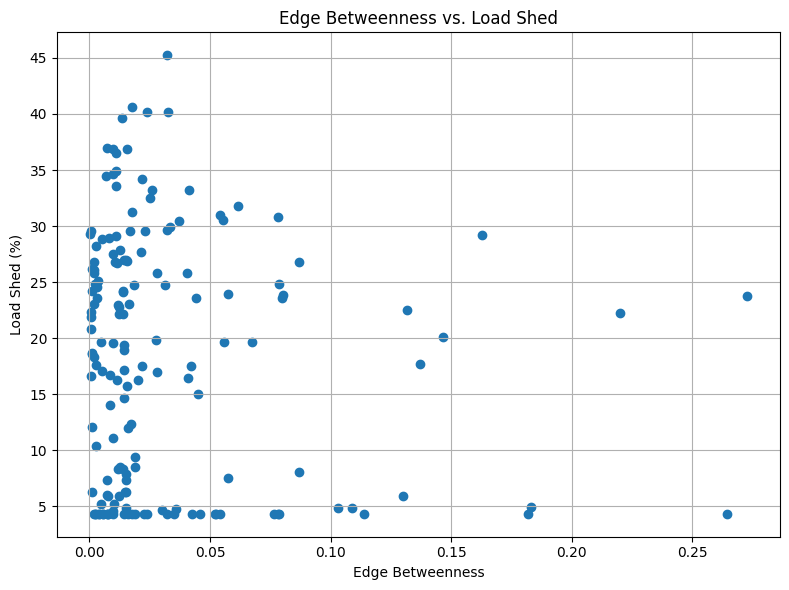

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(valid_edge_compare["edge_betweenness"], valid_edge_compare["shed_percent"])
plt.xlabel("Edge Betweenness")
plt.ylabel("Load Shed (%)")
plt.title("Edge Betweenness vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Full node-triggered cascade scan

In [10]:
node_results = []

for bus_id in net.bus.index:
    node_results.append(
        run_node_cascade(
            net,
            bus_id=int(bus_id),
            alpha=BASE_ALPHA,
            min_base_loading=BASE_MIN_LOADING
        )
    )

node_cascade_df = pd.DataFrame(node_results)
print(node_cascade_df.sort_values(["shed_percent", "cascade_size"], ascending=False).head(15))

     initial_line                  initial_lines  cascade_size                                      tripped_lines  iterations  solver_failed  lcc_size  \
20            NaN                       [25, 26]            91  [25, 26, 22, 23, 24, 28, 166, 32, 38, 40, 41, ...           8          False        21   
36            NaN           [43, 44, 46, 47, 48]            97  [43, 44, 46, 47, 48, 13, 14, 15, 16, 17, 19, 2...           4          False        21   
11            NaN  [10, 11, 12, 13, 15, 18, 170]            76  [10, 11, 12, 13, 15, 18, 170, 0, 1, 3, 17, 20,...          10          False        32   
89            NaN                [125, 126, 127]            97  [125, 126, 127, 110, 116, 117, 118, 119, 120, ...          14          False        15   
46            NaN                   [58, 60, 96]            88  [58, 60, 96, 59, 63, 64, 23, 40, 41, 43, 46, 5...           6          False        31   
0             NaN                         [0, 1]            99  [0, 1, 15, 1

## 9. Compare node metrics against simulated node criticality

In [11]:
node_compare_df = node_cent_df.merge(
    node_cascade_df[["initial_bus", "incident_line_count", "cascade_size", "shed_percent", "lcc_size", "solver_failed"]],
    left_on="bus_id",
    right_on="initial_bus",
    how="left"
)

valid_node_compare = node_compare_df[node_compare_df["solver_failed"] == False].copy()

print("Top 15 node comparison rows")
print(valid_node_compare.sort_values(["shed_percent", "cascade_size"], ascending=False).head(15))

Top 15 node comparison rows
    bus_id  degree  node_betweenness  closeness   eigenvector  initial_bus  incident_line_count  cascade_size  shed_percent  lcc_size  solver_failed
51      20       2          0.013587   0.131875  1.436099e-03           20                    2            91     40.971240        21          False
10      36       5          0.139894   0.155369  1.768787e-02           36                    5            97     39.745403        21          False
16      11       7          0.088705   0.112875  9.090365e-04           11                    7            76     38.684583        32          False
88      89       2          0.000442   0.106872  3.579467e-02           89                    3            97     37.859500        15          False
55      46       3          0.009264   0.176421  1.611995e-01           46                    3            88     37.718058        31          False
93       0       2          0.000123   0.090899  1.513821e-04            0    

In [12]:
def safe_corr(x, y, method="pearson"):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(df) < 2:
        return np.nan
    if method == "pearson":
        return pearsonr(df["x"], df["y"])[0]
    if method == "spearman":
        return spearmanr(df["x"], df["y"])[0]
    raise ValueError("method must be 'pearson' or 'spearman'")


metrics_to_test = ["degree", "node_betweenness", "closeness", "eigenvector"]
targets_to_test = ["shed_percent", "cascade_size"]

node_metric_rows = []

for metric in metrics_to_test:
    for target in targets_to_test:
        node_metric_rows.append({
            "metric": metric,
            "target": target,
            "pearson": safe_corr(valid_node_compare[metric], valid_node_compare[target], method="pearson"),
            "spearman": safe_corr(valid_node_compare[metric], valid_node_compare[target], method="spearman")
        })

node_metric_results_df = pd.DataFrame(node_metric_rows)
print(node_metric_results_df.sort_values(["target", "spearman"], ascending=False))

             metric        target   pearson  spearman
0            degree  shed_percent  0.321864  0.367335
2  node_betweenness  shed_percent  0.101518  0.184004
6       eigenvector  shed_percent -0.028420 -0.042670
4         closeness  shed_percent -0.001172 -0.083770
1            degree  cascade_size  0.263728  0.311377
3  node_betweenness  cascade_size  0.076771  0.171700
7       eigenvector  cascade_size -0.065910 -0.085887
5         closeness  cascade_size -0.046858 -0.138177


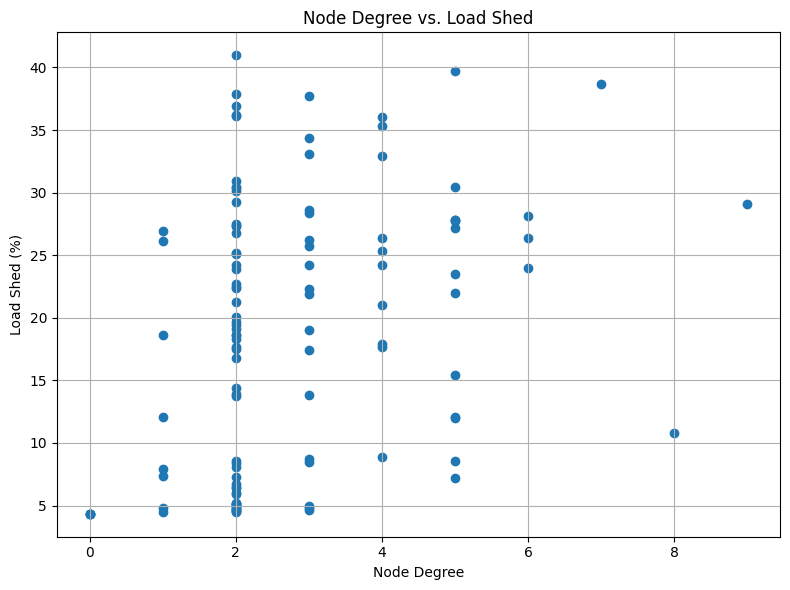

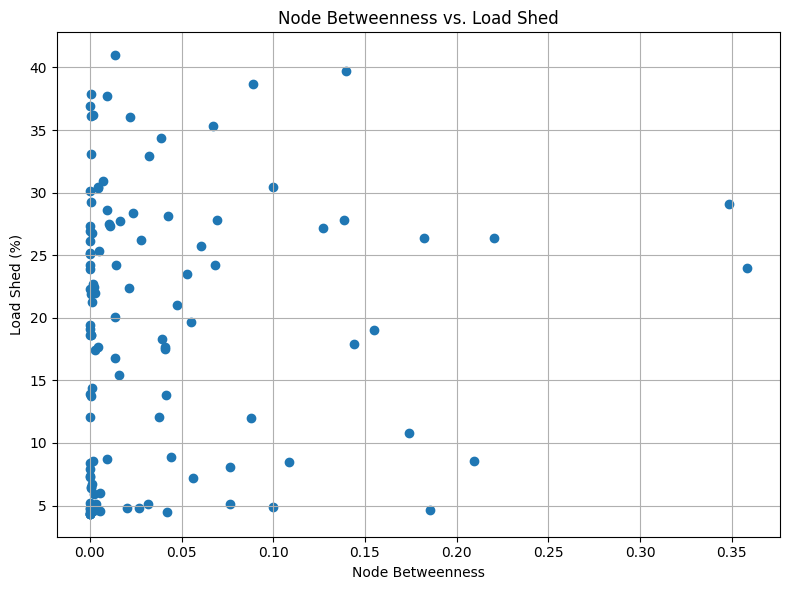

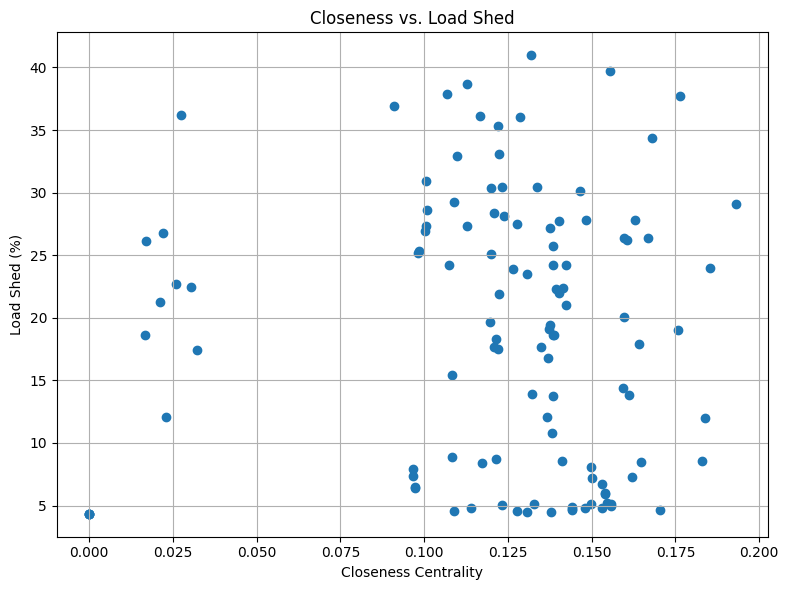

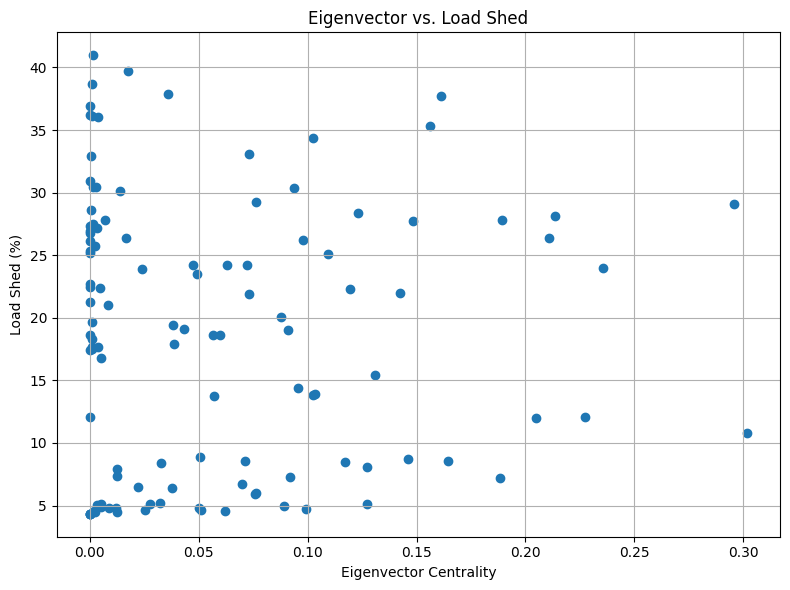

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(valid_node_compare["degree"], valid_node_compare["shed_percent"])
plt.xlabel("Node Degree")
plt.ylabel("Load Shed (%)")
plt.title("Node Degree vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(valid_node_compare["node_betweenness"], valid_node_compare["shed_percent"])
plt.xlabel("Node Betweenness")
plt.ylabel("Load Shed (%)")
plt.title("Node Betweenness vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(valid_node_compare["closeness"], valid_node_compare["shed_percent"])
plt.xlabel("Closeness Centrality")
plt.ylabel("Load Shed (%)")
plt.title("Closeness vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(valid_node_compare["eigenvector"], valid_node_compare["shed_percent"])
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Load Shed (%)")
plt.title("Eigenvector vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Top-10 overlap checks for node metrics

In [14]:
def top_k_overlap(df, metric_col, target_col, k=10):
    top_metric = set(df.nlargest(k, metric_col)["bus_id"])
    top_target = set(df.nlargest(k, target_col)["bus_id"])
    overlap = len(top_metric & top_target)
    union = len(top_metric | top_target)
    jaccard = overlap / union if union > 0 else np.nan
    return overlap, jaccard, top_metric, top_target


overlap_rows = []

for metric in metrics_to_test:
    overlap_shed, jaccard_shed, top_metric_shed, top_target_shed = top_k_overlap(
        valid_node_compare, metric, "shed_percent", k=10
    )
    overlap_cascade, jaccard_cascade, top_metric_cascade, top_target_cascade = top_k_overlap(
        valid_node_compare, metric, "cascade_size", k=10
    )

    overlap_rows.append({
        "metric": metric,
        "top10_overlap_vs_shed": overlap_shed,
        "top10_jaccard_vs_shed": jaccard_shed,
        "top10_overlap_vs_cascade": overlap_cascade,
        "top10_jaccard_vs_cascade": jaccard_cascade
    })

overlap_df = pd.DataFrame(overlap_rows)
print(overlap_df.sort_values("top10_overlap_vs_shed", ascending=False))

             metric  top10_overlap_vs_shed  top10_jaccard_vs_shed  top10_overlap_vs_cascade  top10_jaccard_vs_cascade
0            degree                      2               0.111111                         1                  0.052632
1  node_betweenness                      1               0.052632                         2                  0.111111
2         closeness                      1               0.052632                         2                  0.111111
3       eigenvector                      0               0.000000                         0                  0.000000


## 11. Combined summary table for node metrics

In [15]:
summary_rows = []

for metric in metrics_to_test:
    overlap_shed, jaccard_shed, _, _ = top_k_overlap(valid_node_compare, metric, "shed_percent", k=10)
    overlap_cascade, jaccard_cascade, _, _ = top_k_overlap(valid_node_compare, metric, "cascade_size", k=10)

    summary_rows.append({
        "metric": metric,
        "pearson_vs_shed": safe_corr(valid_node_compare[metric], valid_node_compare["shed_percent"], method="pearson"),
        "spearman_vs_shed": safe_corr(valid_node_compare[metric], valid_node_compare["shed_percent"], method="spearman"),
        "pearson_vs_cascade": safe_corr(valid_node_compare[metric], valid_node_compare["cascade_size"], method="pearson"),
        "spearman_vs_cascade": safe_corr(valid_node_compare[metric], valid_node_compare["cascade_size"], method="spearman"),
        "top10_overlap_vs_shed": overlap_shed,
        "top10_jaccard_vs_shed": jaccard_shed,
        "top10_overlap_vs_cascade": overlap_cascade,
        "top10_jaccard_vs_cascade": jaccard_cascade
    })

node_metric_summary_df = pd.DataFrame(summary_rows)
print(node_metric_summary_df.sort_values("spearman_vs_shed", ascending=False))

             metric  pearson_vs_shed  spearman_vs_shed  pearson_vs_cascade  spearman_vs_cascade  top10_overlap_vs_shed  top10_jaccard_vs_shed  \
0            degree         0.321864          0.367335            0.263728             0.311377                      2               0.111111   
1  node_betweenness         0.101518          0.184004            0.076771             0.171700                      1               0.052632   
3       eigenvector        -0.028420         -0.042670           -0.065910            -0.085887                      0               0.000000   
2         closeness        -0.001172         -0.083770           -0.046858            -0.138177                      1               0.052632   

   top10_overlap_vs_cascade  top10_jaccard_vs_cascade  
0                         1                  0.052632  
1                         2                  0.111111  
3                         0                  0.000000  
2                         2                  0.111

## 12. Sensitivity sweep

In [16]:
def evaluate_edge_setting(net_obj, edge_cent_df, alpha, min_base_loading):
    results = []

    for line_id in net_obj.line.index:
        results.append(
            run_cascade(
                net_obj,
                initial_line=int(line_id),
                alpha=alpha,
                min_base_loading=min_base_loading
            )
        )

    temp_df = pd.DataFrame(results)

    compare_df = edge_cent_df.merge(
        temp_df[["initial_line", "cascade_size", "shed_percent", "solver_failed"]],
        left_on="line_id",
        right_on="initial_line",
        how="left"
    )

    valid_df = compare_df[compare_df["solver_failed"] == False].copy()

    top10_metric = set(valid_df.nlargest(10, "edge_betweenness")["line_id"])
    top10_shed = set(valid_df.nlargest(10, "shed_percent")["line_id"])
    union = len(top10_metric | top10_shed)
    top10_overlap = len(top10_metric & top10_shed)
    top10_jaccard = top10_overlap / union if union > 0 else np.nan

    return {
        "alpha": alpha,
        "min_base_loading": min_base_loading,
        "mean_shed_percent": temp_df["shed_percent"].mean(),
        "max_shed_percent": temp_df["shed_percent"].max(),
        "mean_cascade_size": temp_df["cascade_size"].mean(),
        "max_cascade_size": temp_df["cascade_size"].max(),
        "spearman_betweenness_vs_shed": safe_corr(valid_df["edge_betweenness"], valid_df["shed_percent"], method="spearman"),
        "spearman_betweenness_vs_cascade": safe_corr(valid_df["edge_betweenness"], valid_df["cascade_size"], method="spearman"),
        "top10_overlap": top10_overlap,
        "top10_jaccard": top10_jaccard
    }


alphas = [0.10, 0.20, 0.30, 0.40]
min_base_loadings = [0.01, 0.05, 0.10]

sweep_rows = []

for alpha, min_base_loading in product(alphas, min_base_loadings):
    sweep_rows.append(evaluate_edge_setting(net, edge_cent_df, alpha, min_base_loading))

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.sort_values(["mean_shed_percent", "max_shed_percent"], ascending=False))

    alpha  min_base_loading  mean_shed_percent  max_shed_percent  mean_cascade_size  max_cascade_size  spearman_betweenness_vs_shed  \
2     0.1              0.10          29.109810         61.103253          64.213873               128                      0.047132   
1     0.1              0.05          29.079423         60.419613          67.976879               128                      0.025013   
0     0.1              0.01          29.074245         51.697313          68.890173               117                      0.024506   
3     0.2              0.01          19.120793         42.197077          50.797688               100                     -0.106146   
4     0.2              0.05          19.062472         42.456388          50.265896                99                     -0.104244   
5     0.2              0.10          18.476806         45.238095          47.138728               109                     -0.048692   
7     0.3              0.05          12.156170         

## 13. Sensitivity heatmaps

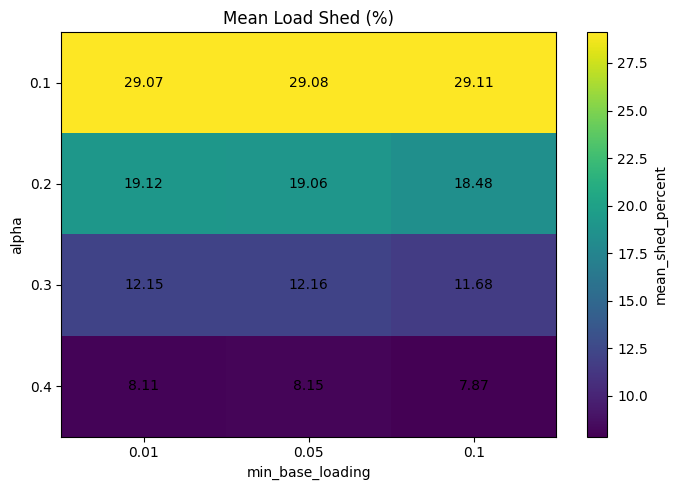

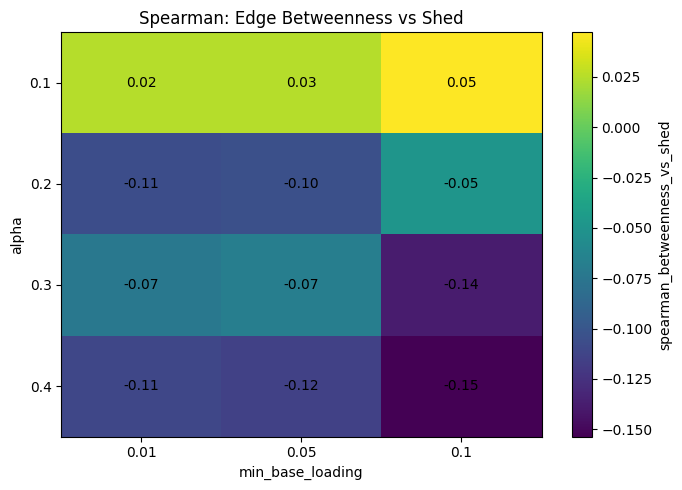

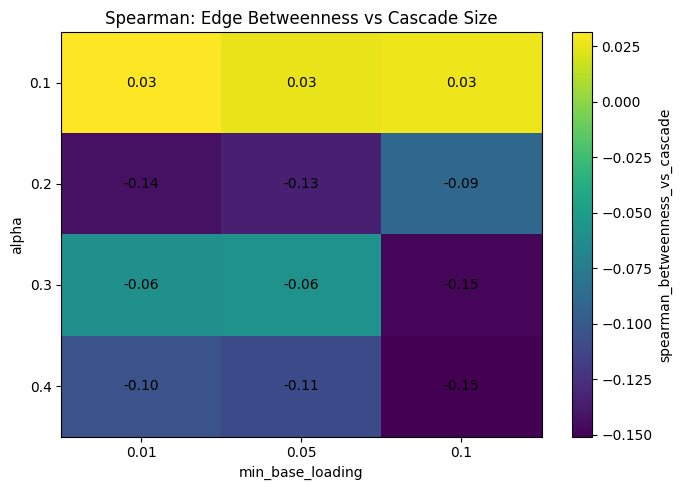

In [17]:
def plot_heatmap(df, value_col, title):
    pivot = df.pivot(index="alpha", columns="min_base_loading", values=value_col)

    plt.figure(figsize=(7, 5))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=value_col)
    plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
    plt.xlabel("min_base_loading")
    plt.ylabel("alpha")
    plt.title(title)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            plt.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()
    return pivot


mean_shed_pivot = plot_heatmap(sweep_df, "mean_shed_percent", "Mean Load Shed (%)")
spearman_shed_pivot = plot_heatmap(sweep_df, "spearman_betweenness_vs_shed", "Spearman: Edge Betweenness vs Shed")
spearman_cascade_pivot = plot_heatmap(sweep_df, "spearman_betweenness_vs_cascade", "Spearman: Edge Betweenness vs Cascade Size")

## 14. Final quick-access tables

In [18]:
top_edge_failures = cascade_df.sort_values(["shed_percent", "cascade_size"], ascending=False).head(10)
top_node_failures = node_cascade_df.sort_values(["shed_percent", "cascade_size"], ascending=False).head(10)

print("Top 10 edge-triggered cascades")
print(top_edge_failures)

print("\nTop 10 node-triggered cascades")
print(top_node_failures)

print("\nNode metric summary")
print(node_metric_summary_df.sort_values("spearman_vs_shed", ascending=False))

Top 10 edge-triggered cascades
     initial_line initial_lines  cascade_size                                      tripped_lines  iterations  solver_failed  lcc_size  served_load_mw  \
19             19          [19]            99  [19, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 2...           8          False        23          2323.0   
25             25          [25]            87  [25, 22, 23, 24, 28, 40, 41, 46, 49, 99, 102, ...           8          False        28          2518.0   
26             26          [26]            90  [26, 22, 23, 24, 28, 166, 32, 38, 40, 41, 46, ...           8          False        21          2536.0   
27             27          [27]            80  [27, 21, 22, 23, 24, 28, 32, 37, 38, 41, 165, ...           9          False        32          2536.0   
125           125         [125]            98  [125, 126, 127, 130, 110, 116, 117, 118, 119, ...          15          False        15          2561.0   
126           126         [126]            98  [126